In [16]:
print("ML Model Train : Spam Email Detection")

ML Model Train : Spam Email Detection


In [24]:
"""Import Required Libraries"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 200)

In [25]:
"""Load Dataset"""

df = pd.read_csv("../data/email_spam_data.csv")
print("Dataset Shapte : " , df.shape)
print("\nColumns : \n", df.columns)

Dataset Shapte :  (33716, 5)

Columns : 
 Index(['Message ID', 'Subject', 'Message', 'Spam/Ham', 'Date'], dtype='str')


In [26]:
"""Data Cleaning and Preparation"""

# Fill missing values
df['Subject'] = df['Subject'].fillna('')
df['Message'] = df['Message'].fillna('')

# Combine Subject + Message into one text column
df['text'] = df['Subject'] + " " + df['Message']

# Convert Spam/Ham to numeric labels
df['label'] = df['Spam/Ham'].map({
    'ham': 0,
    'spam': 1
})

# Remove duplicates
df = df.drop_duplicates(subset=['text'])

# Reset index
df.reset_index(drop=True, inplace=True)

print("Cleaned Dataset Shape:", df.shape)
df[['text', 'label']].head()

Cleaned Dataset Shape: (30494, 7)


,text,label
0,christmas tree farm pictures,0
1,"vastar resources , inc . gary , production from the high island larger block a - 1 # 2 commenced on\nsaturday at 2 : 00 p . m . at about 6 , 500 gross . carlos expects between 9 , 500 and\n10 , 00...",0
2,calpine daily gas nomination - calpine daily gas nomination 1 . doc,0
3,re : issue fyi - see note below - already done .\nstella\n- - - - - - - - - - - - - - - - - - - - - - forwarded by stella l morris / hou / ect on 12 / 14 / 99 10 : 18\nam - - - - - - - - - - - - -...,0
4,meter 7268 nov allocation fyi .\n- - - - - - - - - - - - - - - - - - - - - - forwarded by lauri a allen / hou / ect on 12 / 14 / 99 12 : 17\npm - - - - - - - - - - - - - - - - - - - - - - - - - - ...,0


label
0    15910
1    14584
Name: count, dtype: int64


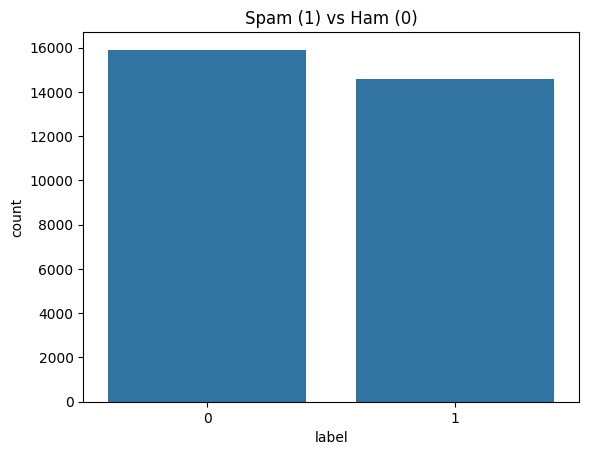

In [28]:
"""Class Distribution"""

print(df['label'].value_counts())

sns.countplot(x='label', data=df)
plt.title("Spam (1) vs Ham (0)")
plt.show()

In [32]:
"""Feature and Target Separation"""

X = df['text']
y = df['label']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (30494,)
Target Shape: (30494,)


In [34]:
"""Train-Test Split"""

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 24395
Testing Samples: 6099


In [36]:
"""TF-IDF Vectorization"""

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.95,
    min_df=2,
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Train Shape:", X_train_tfidf.shape)

TF-IDF Train Shape: (24395, 5000)


In [46]:
"""Model 1 : Logistic Regression"""

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9880308247253649

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3182
           1       0.98      0.99      0.99      2917

    accuracy                           0.99      6099
   macro avg       0.99      0.99      0.99      6099
weighted avg       0.99      0.99      0.99      6099



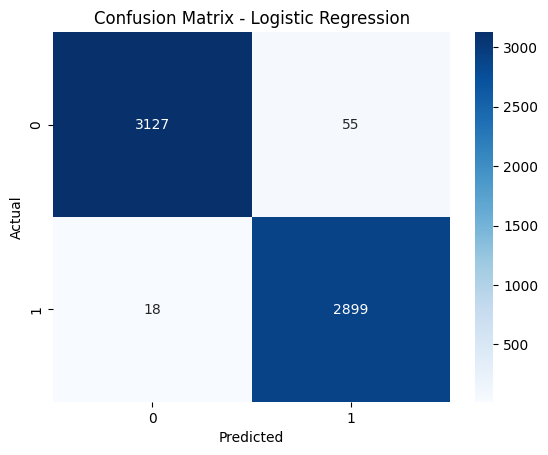

In [47]:
"""Confusion Matrix (Logistic Regression)"""

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [49]:
"""Model 2 : Naive Bayes"""

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.9811444499098213

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3182
           1       0.98      0.98      0.98      2917

    accuracy                           0.98      6099
   macro avg       0.98      0.98      0.98      6099
weighted avg       0.98      0.98      0.98      6099



In [53]:
"""Compare Models"""

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.988031
1,Naive Bayes,0.981144


In [76]:
"""Testing Custom Email"""

def predict_email_with_prob(text):
    text_tfidf = vectorizer.transform([text])
    prediction = lr_model.predict(text_tfidf)[0]
    prob = lr_model.predict_proba(text_tfidf)[0]

    return prediction, prob

In [78]:
"""Input Email For Testing"""

text = input("Enter a email : ")
prediction, prob = predict_email_with_prob(text)

print("Prediction:", "Spam" if prediction==1 else "Ham")
print("Probability:", prob)

Prediction: Ham
Probability: [0.99537423 0.00462577]
